### Custom Object Detection with Detectron2

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!python -m pip install pyyaml==5.1
import sys, os, distutils.core

!git clone 'https://github.com/facebookresearch/detectron2'
dist = distutils.core.run_setup("./detectron2/setup.py")
!python -m pip install {' '.join([f"'{x}'" for x in dist.install_requires])}
sys.path.insert(0, os.path.abspath('./detectron2'))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.2/274.2 kB 9.9 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
Cloning into 'detectron2'...
remote: Enumerating objects: 15912, done.
remote: Total 15912 (delta 0), reused 0 (delta 0), pack-reused 15912 (from 1)
Receiving objects: 100% (15912/15912), 6.68 MiB | 11.18 MiB/s, done.
Resolving deltas: 100% (11329/11329), done.
Ignoring dataclasses: markers 'python_version < "3.7"' don't match your environment
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.1 MB/s eta 0:00:00
  Prepar

In [4]:
import torch ,detectron2
!nvcc --version
TORCH_VERSION = ".".join(torch.__version__.split(".")[:2])
CUDA_VERSION = torch.__version__.split("+")[-1]
print("torch: ", TORCH_VERSION, "; cuda: ", CUDA_VERSION)
print("detectron2:", detectron2.__version__)

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:18:23_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0
torch:  2.8 ; cuda:  cu126
detectron2: 0.6


### Imports

In [5]:
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()
## Some common libraries
import numpy as np
import os, json, cv2, random
from google.colab.patches import cv2_imshow
## import some common detectron2 utilities
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog

## Lets get our dataset

In [5]:
#from google.colab import drive
#drive.mount('/content/drive')

In [6]:
%cd /content/drive/MyDrive/HeadDataset

/content/drive/MyDrive/HeadDataset


In [ ]:
#!unzip /content/drive/MyDrive/HeadDataset/Dataset_worker.zip

Streaming output truncated to the last 5000 lines.
  inflating: Dataset_worker/train/001347_jpg.rf.460c45472e8e559548333218a3efc572.jpg  
  inflating: Dataset_worker/train/001348_jpg.rf.1aaa9816491996825a47db9788df151d.jpg  
  inflating: Dataset_worker/train/001349_jpg.rf.a0408b75692819b5bfd8c2bb962eaf5d.jpg  
  inflating: Dataset_worker/train/001350_jpg.rf.de9536b247379a11b76fc8f444c4b713.jpg  
  inflating: Dataset_worker/train/001351_jpg.rf.a79f8541415bd4094b7d8435f6d9c1a9.jpg  
  inflating: Dataset_worker/train/001352_jpg.rf.b718c79a2fda13186e41a6cafd49fa13.jpg  
  inflating: Dataset_worker/train/001353_jpg.rf.47085a76256908fc10410be9f34ab7b4.jpg  
  inflating: Dataset_worker/train/001354_jpg.rf.03c92d8799e95f4ebf9473d19b71ab03.jpg  
  inflating: Dataset_worker/train/001355_jpg.rf.7da02fbe046934642d3aa6d524f7cf21.jpg  
  inflating: Dataset_worker/train/001356_jpg.rf.631c2ba8e2e94fda0a4d452557f281d2.jpg  
  inflating: Dataset_worker/train/001357_jpg.rf.8bd08ceb5ba66e05a38f06bdd82bb04

In [7]:
!cat /content/drive/MyDrive/HeadDataset/Dataset_worker/train/_annotations.coco.json

{"info":{"year":"2022","version":"10","description":"Exported from roboflow.ai","contributor":"Northeastern University - China","url":"https://public.roboflow.ai/object-detection/hard-hat-workers","date_created":"2022-10-18T17:17:06+00:00"},"licenses":[{"id":1,"url":"https://creativecommons.org/publicdomain/zero/1.0/","name":"Public Domain"}],"categories":[{"id":0,"name":"Workers","supercategory":"none"},{"id":1,"name":"head","supercategory":"Workers"},{"id":2,"name":"helmet","supercategory":"Workers"},{"id":3,"name":"person","supercategory":"Workers"}],"images":[{"id":0,"license":1,"file_name":"002609_jpg.rf.09f46a076cdaf6d8f78e65cc00e072b0.jpg","height":264,"width":400,"date_captured":"2022-10-18T17:17:06+00:00"},{"id":1,"license":1,"file_name":"004553_jpg.rf.09a67ed2a825723a2494abc67aa4dc6e.jpg","height":300,"width":450,"date_captured":"2022-10-18T17:17:06+00:00"},{"id":2,"license":1,"file_name":"000453_jpg.rf.0a0adfd2ca91ca10f8991a11aef0cc11.jpg","height":333,"width":500,"date_capt

## Register Dataset

In [8]:
from detectron2.data.datasets import register_coco_instances
register_coco_instances("my_dataset_train", {}, "/content/drive/MyDrive/HeadDataset/Dataset_worker/train/_annotations.coco.json", "/content/drive/MyDrive/HeadDataset/Dataset_worker/train")
register_coco_instances("my_dataset_val", {}, "/content/drive/MyDrive/HeadDataset/Dataset_worker/val/_annotations.coco.json", "/content/drive/MyDrive/HeadDataset/Dataset_worker/valid")
register_coco_instances("my_dataset_test", {}, "/content/drive/MyDrive/HeadDataset/Dataset_worker/test/_annotations.coco.json", "/content/drive/MyDrive/HeadDataset/Dataset_worker/test")

WARNING [09/06 12:55:44 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[09/06 12:55:44 d2.data.datasets.coco]: Loaded 4916 images in COCO format from /content/drive/MyDrive/HeadDataset/Dataset_worker/train/_annotations.coco.json


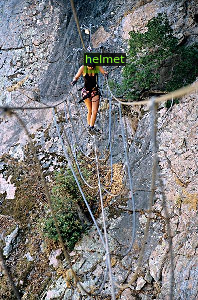

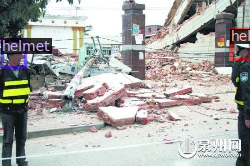

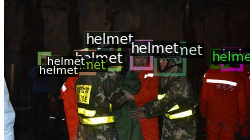

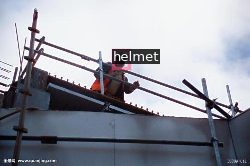

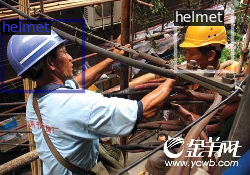

In [9]:
### visuallizaing the training data
my_dataset_train_metadata = MetadataCatalog.get("my_dataset_train")
dataset_dicts = DatasetCatalog.get("my_dataset_train")

import random
from detectron2.utils.visualizer import Visualizer

for d in random.sample(dataset_dicts, 5):
    img = cv2.imread(d["file_name"])
    visualizer = Visualizer(img[:, :, ::-1], metadata=my_dataset_train_metadata, scale=0.5)
    vis = visualizer.draw_dataset_dict(d)
    cv2_imshow(vis.get_image()[:, :, ::-1])

## Training

In [10]:
from detectron2.engine import DefaultTrainer

cfg=get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"))
cfg.DATASETS.TRAIN = ("my_dataset_train")
cfg.DATALOADER.NUM_WORKERS = 2
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml") ## TRINING START FROM MODEL ZOO
cfg.SOLVER.IMS_PER_BATCH = 2
cfg.SOLVER.BASE_LR = 0.00025 ## PICK A GOOD LR
cfg.SOLVER.MAX_ITER = 500 # 300 iterations seems good enough for this toy dataset; you will need to train longer for a practical dataset
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128  # faster, and good enough for this toy dataset (default: 512)
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 3 # (see https://detectron2.readthedocs.io/tutorials/datasets.html#update-the-config-for-new-datasets)
# NOTE: this config means the number of classes, but a few popular unofficial tutorials incorrect uses num_classes+1 here.
#cfg.MODEL.DEVICE = "cpu"
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=False)
trainer.train()



[09/06 12:55:48 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

model_final_280758.pkl: 167MB [00:00, 235MB/s]                           
roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, weight}


[09/06 12:55:49 d2.engine.train_loop]: Starting training from iteration 0


/usr/local/lib/python3.12/dist-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4322.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


[09/06 12:56:01 d2.utils.events]:  eta: 0:03:29  iter: 19  total_loss: 1.924  loss_cls: 1.466  loss_box_reg: 0.2792  loss_rpn_cls: 0.1205  loss_rpn_loc: 0.02946    time: 0.4344  last_time: 0.4024  data_time: 0.0676  last_data_time: 0.0056   lr: 9.7405e-06  max_mem: 2635M
[09/06 12:56:15 d2.utils.events]:  eta: 0:03:18  iter: 39  total_loss: 1.861  loss_cls: 1.334  loss_box_reg: 0.3804  loss_rpn_cls: 0.1501  loss_rpn_loc: 0.02922    time: 0.4305  last_time: 0.4774  data_time: 0.0253  last_data_time: 0.0750   lr: 1.9731e-05  max_mem: 2635M
[09/06 12:56:23 d2.utils.events]:  eta: 0:03:07  iter: 59  total_loss: 1.475  loss_cls: 1.044  loss_box_reg: 0.3093  loss_rpn_cls: 0.07954  loss_rpn_loc: 0.01913    time: 0.4268  last_time: 0.4460  data_time: 0.0299  last_data_time: 0.0156   lr: 2.972e-05  max_mem: 2635M
[09/06 12:56:33 d2.utils.events]:  eta: 0:03:00  iter: 79  total_loss: 1.32  loss_cls: 0.7655  loss_box_reg: 0.5149  loss_rpn_cls: 0.07266  loss_rpn_loc: 0.02705    time: 0.4353  last_

FileNotFoundError: [Errno 2] No such file or directory: 'datasets/coco/annotations/instances_val2017.json'

In [11]:
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5   # set the testing threshold for this model
cfg.DATASETS.TEST = ("my_dataset_train", )
predictor = DefaultPredictor(cfg)

[09/06 12:59:56 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./output/model_final.pth ...


### Visualizing Results

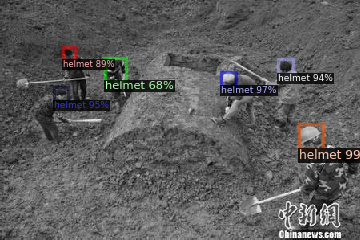

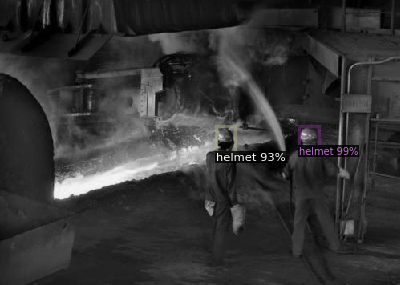

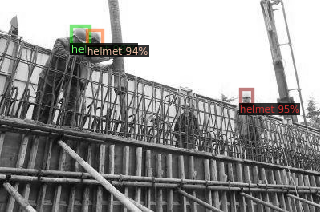

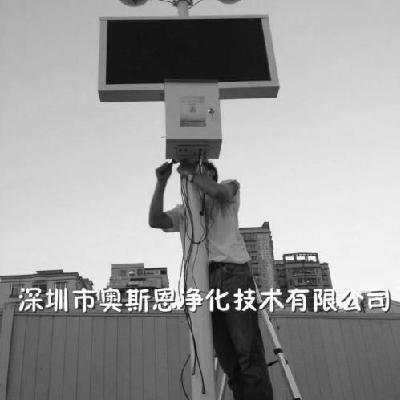

In [12]:
from detectron2.utils.visualizer import ColorMode

for d in random.sample(dataset_dicts, 4):
    im = cv2.imread(d["file_name"])
    outputs = predictor(im)
    v = Visualizer(im[:, :, ::-1],
                   metadata=my_dataset_train_metadata, # Use the correct metadata variable
                   scale=0.8,
                   instance_mode=ColorMode.IMAGE_BW   # remove the colors of unsegmented pixels
    )
    v = v.draw_instance_predictions(outputs["instances"].to("cpu"))
    cv2_imshow(v.get_image()[:, :, ::-1])

### Evaluation

In [13]:
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader
evaluator = COCOEvaluator("my_dataset_test", output_dir= "./output")
val_loader = build_detection_test_loader(cfg, "my_dataset_test")
print(inference_on_dataset(predictor.model, val_loader, evaluator))

[09/06 13:00:08 d2.evaluation.coco_evaluation]: Fast COCO eval is not built. Falling back to official COCO eval.
WARNING [09/06 13:00:09 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[09/06 13:00:09 d2.data.datasets.coco]: Loaded 706 images in COCO format from /content/drive/MyDrive/HeadDataset/Dataset_worker/test/_annotations.coco.json
[09/06 13:00:09 d2.data.build]: Distribution of instances among all 4 categories:
|  category  | #instances   |  category  | #instances   |  category  | #instances   |
|:----------:|:-------------|:----------:|:-------------|:----------:|:-------------|
|  Workers   | 0            |    head    | 726          |   helmet   | 1915         |
|   person   | 64           |            |              |            |              |
|   total    | 2705         |            |              |            |              |
[09/06 13:00:09 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in in

### Getting the custom config file

In [14]:
f = open('config.yml', 'w')
f.write(cfg.dump())
f.close()